# 1. Introduction

Customer retention is one of the most important challenges faced by telecommunication companies. Acquiring new customers is significantly more expensive than retaining existing ones, making customer churn a critical business concern.

This project analyzes customer data from a telecommunications company to identify the key factors influencing customer churn. By exploring customer demographics, service usage, billing information, and contract details, the analysis aims to uncover patterns that explain why customers leave and provide actionable recommendations to improve customer retention.

The project follows a business analytics approach by combining exploratory data analysis (EDA), statistical summaries, and data visualization to support data-driven decision-making.


# 2. Business Problem

Customer churn negatively impacts revenue, profitability, and long-term business growth. Understanding the characteristics of customers who are likely to leave allows organizations to implement targeted retention strategies and reduce customer attrition.

The primary business problem addressed in this project is:

> **Which factors contribute most to customer churn, and what actions can the company take to improve customer retention?**

This analysis seeks to answer that question by identifying meaningful trends, relationships, and customer segments associated with churn.

# 3. Project Objectives

The objectives of this analysis are to:

- Understand the structure and quality of the dataset.
- Perform data cleaning and preprocessing.
- Explore customer demographics and service characteristics.
- Identify factors associated with customer churn.
- Discover patterns and trends through visualization.
- Generate business insights based on the findings.
- Provide practical recommendations to reduce customer churn.

# 4. Dataset Description

The dataset used in this project is the **Telco Customer Churn Dataset**, which contains customer information from a telecommunications company.

Each row represents a unique customer and includes demographic information, subscribed services, account details, billing information, and whether the customer churned.

The dataset contains features such as:

- Customer ID
- Gender
- Senior Citizen Status
- Partner Status
- Dependents
- Tenure
- Phone Service
- Internet Service
- Contract Type
- Payment Method
- Monthly Charges
- Total Charges
- Churn Status

This dataset is widely used for customer retention and business analytics case studies because it provides multiple variables that influence customer behavior.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option('display.max_columns', None)

# Improve plot appearance
# plt.style.use('ggplot')
plt.style.use('default')
brand_green = "#2E8B57"
brand_blue = "#1F77B4"
brand_orange = "#FF8C42"

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
df= pd.read_csv("customer_churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Dataset dimensions
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 7043
Columns: 21


In [4]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [5]:
# Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


In [7]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [8]:
# Duplicate Records
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


# 6. Initial Findings

The initial exploration provides an overview of the dataset's structure and quality.

The following aspects were assessed:

- Dataset dimensions
- Data types
- Missing values
- Duplicate records
- Summary statistics

These observations will guide the data cleaning process before moving on to exploratory data analysis.

In [9]:
display(df['gender'].unique())
print("=" * 50)
display(df['SeniorCitizen'].unique())
print("=" * 50)
display(df['Partner'].unique())
print("=" * 50)
display(df['Dependents'].unique())
print("=" * 50)
display(df['PhoneService'].unique())
print("=" * 50)
display(df['MultipleLines'].unique())
print("=" * 50)
display(df['InternetService'].unique())
print("=" * 50)
display(df['OnlineSecurity'].unique())
print("=" * 50)
display(df['OnlineBackup'].unique())
print("=" * 50)
display(df['DeviceProtection'].unique())
print("=" * 50)
display(df['TechSupport'].unique())
print("=" * 50)
display(df['StreamingTV'].unique())
print("=" * 50)
display(df['StreamingMovies'].unique())
print("=" * 50)
display(df['Contract'].unique())
print("=" * 50)
display(df['PaperlessBilling'].unique())
print("=" * 50)
display(df['PaymentMethod'].unique())
print("=" * 50)
display(df['Churn'].unique())

array(['Female', 'Male'], dtype=object)

array([0, 1])

array(['Yes', 'No'], dtype=object)

array(['No', 'Yes'], dtype=object)

array(['No', 'Yes'], dtype=object)

...

array(['No', 'Yes', 'No internet service'], dtype=object)

array(['Month-to-month', 'One year', 'Two year'], dtype=object)

array(['Yes', 'No'], dtype=object)

array(['Electronic check', 'Mailed check', 'Bank transfer (automatic)',
       'Credit card (automatic)'], dtype=object)

array(['No', 'Yes'], dtype=object)

In [10]:
(df['TotalCharges'] == ' ').sum()

np.int64(11)

In [11]:
# Convert to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [12]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [13]:
df.dropna(inplace=True)
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

# Why drop instead of fill?

Because:

- It's only 11 records.
- They represent customers with zero tenure, so TotalCharges hasn't accumulated yet.
- Filling with a mean or median would create artificial values.
- Removing 11 rows from over 7,000 won't meaningfully affect the analysis.

# 7. Exploratory Data Analysis (EDA)

The purpose of this exploratory data analysis is to identify patterns, trends, and relationships within the dataset that explain customer churn.

Each visualization addresses a specific business question and contributes to understanding the factors that influence customer retention.

## 7.1 Customer Churn Distribution

### Business Question

How many customers have churned, and what proportion of the customer base do they represent?

Understanding the overall churn rate provides a baseline for evaluating the severity of customer attrition before investigating its underlying causes.

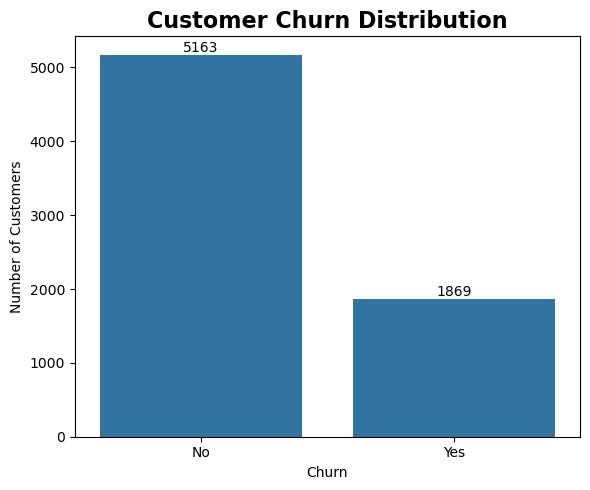

In [14]:
plt.figure(figsize=(6,5))

ax = sns.countplot(
    data=df,
    x='Churn',
    color=brand_blue
)

plt.title('Customer Churn Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

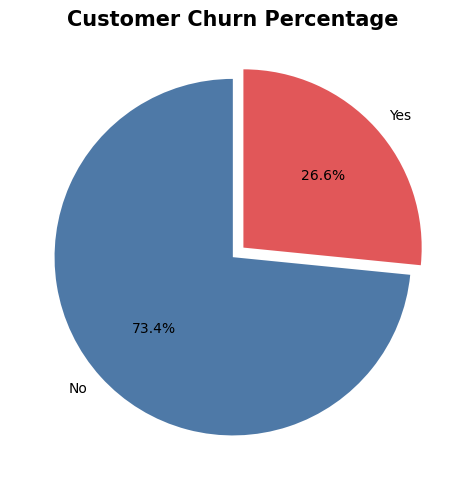

In [15]:
# Percentage Distribution of Customer Churn

churn_counts = df['Churn'].value_counts()

plt.figure(figsize=(6,5))

plt.pie(
    churn_counts,
    labels=churn_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['#4E79A7', '#E15759'],
    explode=(0, 0.08)
)

plt.title('Customer Churn Percentage', fontsize=15, fontweight='bold')

plt.tight_layout()
plt.show()

### Insight

The dataset shows that the majority of customers remained with the company, while a smaller but significant proportion discontinued their services.

Approximately **26.6%** of customers churned, indicating that more than one in every four customers left the company. This represents a considerable customer retention challenge that could negatively affect revenue and long-term business growth.

The next step is to identify the customer characteristics and service-related factors that contribute to this level of churn.

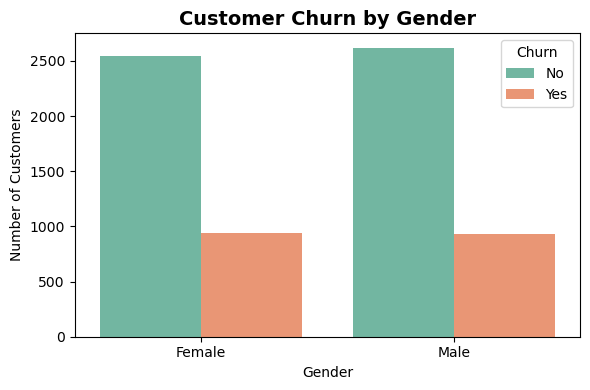

In [16]:
# 1. Churn by Gender

plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='gender',
    hue='Churn',
    palette='Set2'
)

plt.title('Customer Churn by Gender', fontsize=14, fontweight='bold')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')

plt.tight_layout()
plt.show()

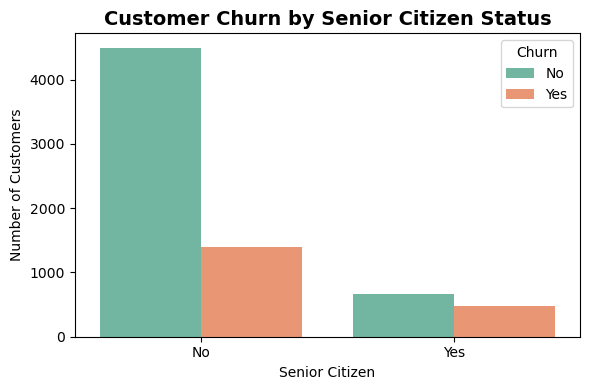

In [17]:
# 2. Churn by Senior Citizen
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='SeniorCitizen',
    hue='Churn',
    palette='Set2'
)

plt.title('Customer Churn by Senior Citizen Status', fontsize=14, fontweight='bold')
plt.xlabel('Senior Citizen')
plt.ylabel('Number of Customers')

plt.xticks([0,1], ['No','Yes'])

plt.tight_layout()
plt.show()

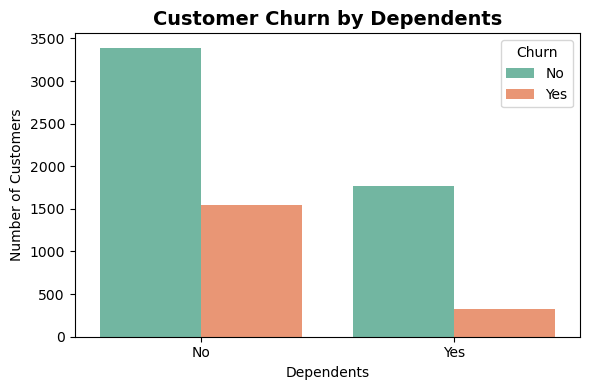

In [18]:
# 4. Churn by Dependents
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='Dependents',
    hue='Churn',
    palette='Set2'
)

plt.title('Customer Churn by Dependents', fontsize=14, fontweight='bold')
plt.xlabel('Dependents')
plt.ylabel('Number of Customers')

plt.tight_layout()
plt.show()

### Key Findings

- Churn appears fairly balanced across male and female customers.
- Senior citizens show a noticeably higher tendency to churn.
- Customers without partners are more likely to leave the company.
- Customers without dependents also exhibit higher churn levels.

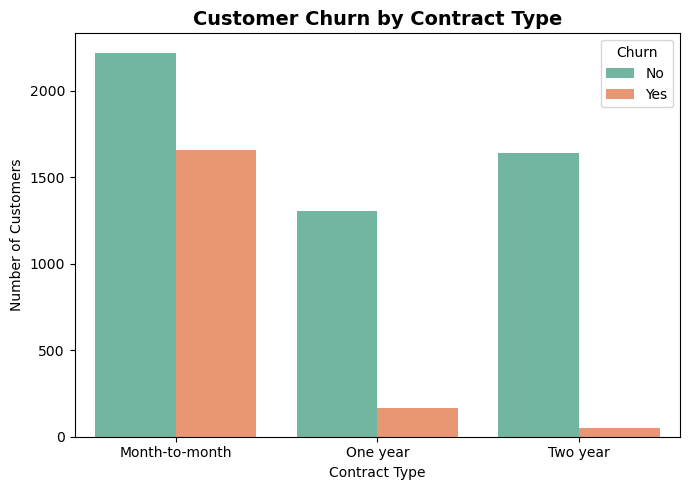

In [19]:
# Contract Type vs Churn
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x='Contract',
    hue='Churn',
    palette='Set2'
)

plt.title('Customer Churn by Contract Type', fontsize=14, fontweight='bold')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')

plt.tight_layout()
plt.show()

In [20]:
# Churn Rate by Contract Type

contract_churn = (
    df.groupby('Contract')['Churn']
      .value_counts(normalize=True)
      .mul(100)
      .rename('Churn Rate (%)')
      .round(2)
)

display(contract_churn)

Contract        Churn
Month-to-month  No       57.29
                Yes      42.71
One year        No       88.72
                Yes      11.28
Two year        No       97.15
                Yes       2.85
Name: Churn Rate (%), dtype: float64

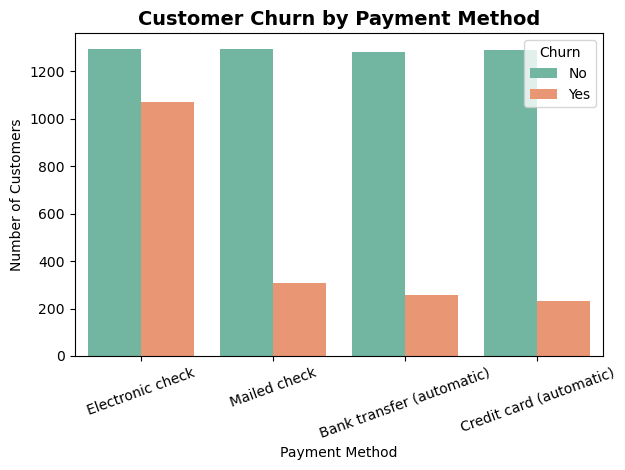

In [21]:
# Payment Method vs Churn

sns.countplot(
    data=df,
    x='PaymentMethod',
    hue='Churn',
    palette='Set2'
)

plt.title('Customer Churn by Payment Method', fontsize=14, fontweight='bold')
plt.xlabel('Payment Method')
plt.ylabel('Number of Customers')

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()


In [22]:
# Churn Rate by Payment Method

payment_churn = (
    df.groupby('PaymentMethod')['Churn']
      .value_counts(normalize=True)
      .mul(100)
      .rename('Churn Rate (%)')
      .round(2)
)

display(payment_churn)

PaymentMethod              Churn
Bank transfer (automatic)  No       83.27
                           Yes      16.73
Credit card (automatic)    No       84.75
                           Yes      15.25
Electronic check           No       54.71
                           Yes      45.29
Mailed check               No       80.80
                           Yes      19.20
Name: Churn Rate (%), dtype: float64

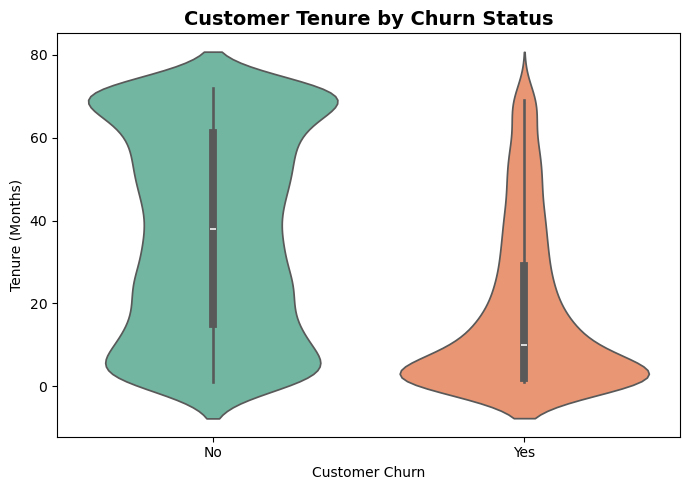

In [23]:
# Customer Tenure vs Churn
plt.figure(figsize=(7,5))

sns.violinplot(
    data=df,
    x='Churn',
    y='tenure',
    palette='Set2'
)

plt.title('Customer Tenure by Churn Status', fontsize=14, fontweight='bold')
plt.xlabel('Customer Churn')
plt.ylabel('Tenure (Months)')

plt.tight_layout()
plt.show()

In [24]:
# Average Tenure by Churn Status

tenure_summary = (
    df.groupby('Churn')['tenure']
      .agg(['mean', 'median', 'min', 'max'])
      .round(2)
)

display(tenure_summary)

,mean,median,min,max
Churn,,,,
No,37.65,38.0,1,72
Yes,17.98,10.0,1,72


### Key Findings

- Month-to-month contracts recorded the highest customer churn rate, indicating that customers without long-term commitments are more likely to leave.
- Customers using certain payment methods experienced higher churn than others, suggesting that payment preferences may influence retention.
- Customers who churn have a noticeably shorter average tenure, showing that customer attrition is most common during the early stages of the customer lifecycle.

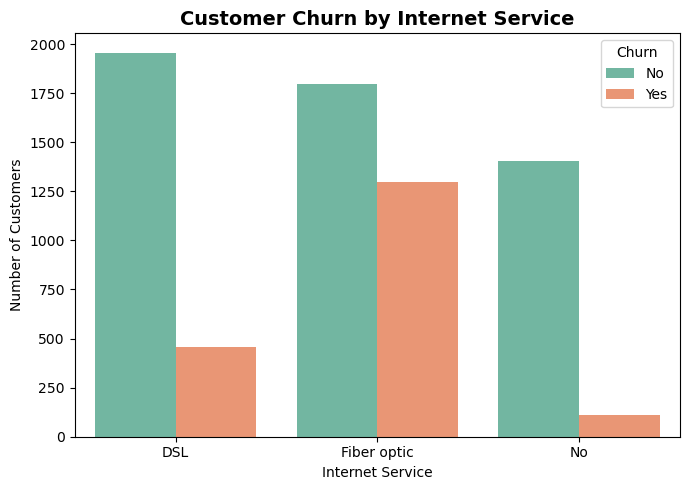

In [25]:
# Internet Service vs Churn
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x='InternetService',
    hue='Churn',
    palette='Set2'
)

plt.title('Customer Churn by Internet Service', fontsize=14, fontweight='bold')
plt.xlabel('Internet Service')
plt.ylabel('Number of Customers')

plt.tight_layout()
plt.show()

In [26]:
internet_churn = (
    df.groupby('InternetService')['Churn']
      .value_counts(normalize=True)
      .mul(100)
      .rename('Churn Rate (%)')
      .round(2)
)

display(internet_churn)

InternetService  Churn
DSL              No       81.00
                 Yes      19.00
Fiber optic      No       58.11
                 Yes      41.89
No               No       92.57
                 Yes       7.43
Name: Churn Rate (%), dtype: float64

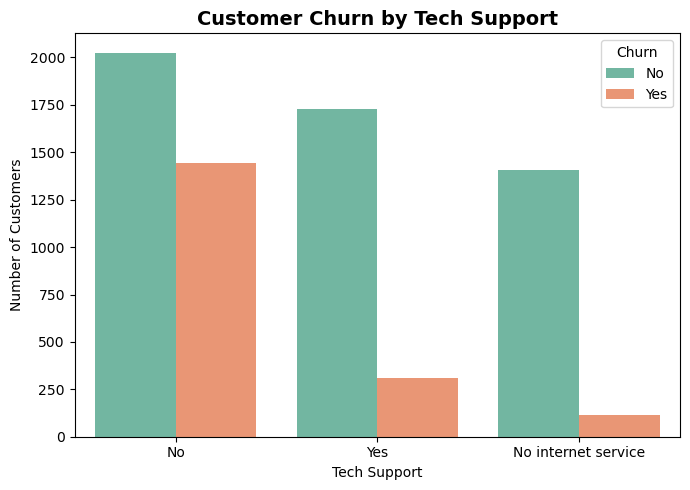

In [27]:
# Tech Support vs Churn
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x='TechSupport',
    hue='Churn',
    palette='Set2'
)

plt.title('Customer Churn by Tech Support', fontsize=14, fontweight='bold')
plt.xlabel('Tech Support')
plt.ylabel('Number of Customers')

plt.tight_layout()
plt.show()

In [28]:
techsupport_churn = (
    df.groupby('TechSupport')['Churn']
      .value_counts(normalize=True)
      .mul(100)
      .rename('Churn Rate (%)')
      .round(2)
)

display(techsupport_churn)

TechSupport          Churn
No                   No       58.35
                     Yes      41.65
No internet service  No       92.57
                     Yes       7.43
Yes                  No       84.80
                     Yes      15.20
Name: Churn Rate (%), dtype: float64

### Key Findings

- Customers using different internet service types exhibit varying churn rates.
- Customers without technical support are more likely to leave the company, suggesting that support services play an important role in customer retention.

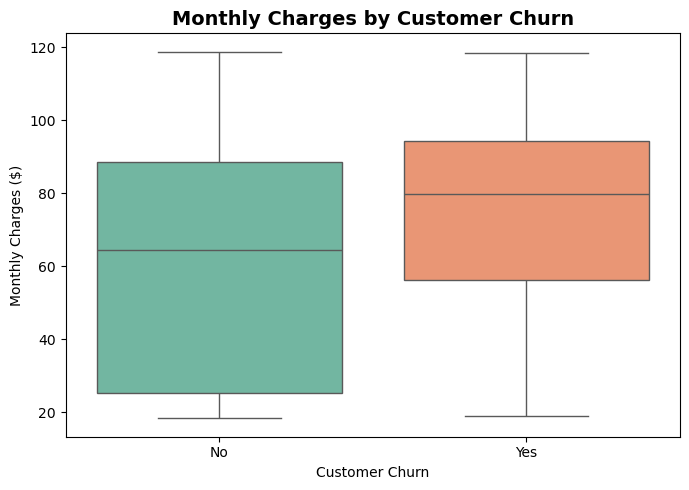

In [29]:
# Monthly Charges by Churn
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x='Churn',
    y='MonthlyCharges',
    palette='Set2'
)

plt.title('Monthly Charges by Customer Churn', fontsize=14, fontweight='bold')
plt.xlabel('Customer Churn')
plt.ylabel('Monthly Charges ($)')

plt.tight_layout()
plt.show()

In [30]:
monthly_summary = (
    df.groupby('Churn')['MonthlyCharges']
      .agg(['mean', 'median', 'min', 'max'])
      .round(2)
)

display(monthly_summary)

,mean,median,min,max
Churn,,,,
No,61.31,64.45,18.25,118.75
Yes,74.44,79.65,18.85,118.35


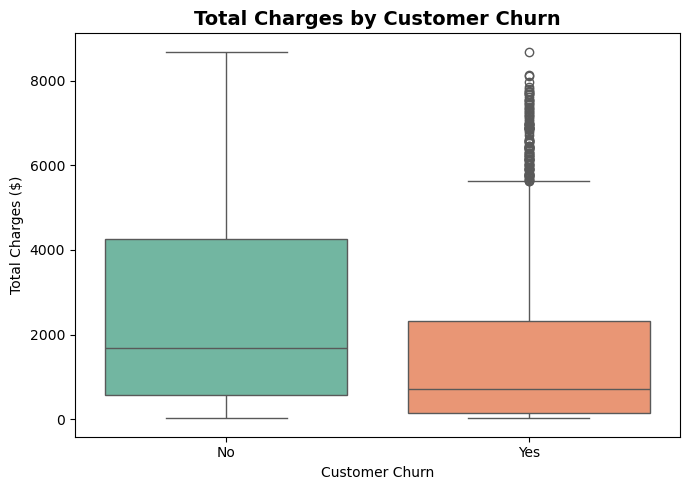

In [31]:
# Total Charges by Churn
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x='Churn',
    y='TotalCharges',
    palette='Set2'
)

plt.title('Total Charges by Customer Churn', fontsize=14, fontweight='bold')
plt.xlabel('Customer Churn')
plt.ylabel('Total Charges ($)')

plt.tight_layout()
plt.show()


In [32]:
total_summary = (
    df.groupby('Churn')['TotalCharges']
      .agg(['mean', 'median', 'min', 'max'])
      .round(2)
)

display(total_summary)

,mean,median,min,max
Churn,,,,
No,2555.34,1683.60,18.80,8672.45
Yes,1531.80,703.55,18.85,8684.80


### Key Findings

- Customers who churn generally incur higher monthly charges than those who remain with the company.
- Total charges tend to be higher among retained customers, reflecting their longer tenure with the company.

# 8. Business Insights

- Approximately one in four customers left the company, indicating a significant customer retention challenge.

- Customers on month-to-month contracts exhibited the highest churn rates, suggesting that the absence of long-term commitments increases the likelihood of customer attrition.

- Customers with shorter tenures were more likely to churn, highlighting the importance of the early stages of the customer lifecycle.

- Higher monthly charges were associated with increased churn, indicating that pricing may influence customer retention.

- Customers without technical support services showed higher churn levels, suggesting that support services contribute to customer loyalty.

- Churn patterns also varied across internet service types and payment methods, indicating that service offerings and billing preferences may influence customer behavior.

# 9. Recommendations

1. Encourage customers to move from month-to-month plans to longer-term contracts by offering attractive discounts or loyalty incentives.

2. Develop targeted onboarding and engagement programs for new customers to improve retention during their first year of service.

3. Review pricing strategies and introduce value-added packages for customers with higher monthly charges.

4. Promote technical support services by bundling them with internet plans or offering free trial periods to improve customer satisfaction.

5. Use churn risk indicators such as contract type, tenure, and monthly charges to identify high-risk customers and implement proactive retention campaigns.

# 10. Conclusion

This analysis identified several key factors influencing customer churn, including contract type, customer tenure, monthly charges, technical support, and internet service. The findings provide actionable insights that can help improve customer retention and support data-driven business decision-making. By implementing targeted retention strategies based on these insights, the company can reduce churn and strengthen long-term customer relationships.

In [33]:
# Export the cleaned dataset

df.to_csv('customer_churn_cleaned.csv', index=False)

print("Cleaned dataset exported successfully!")

Cleaned dataset exported successfully!
